In [41]:
import pandas as pd
import numpy as np
import json
import torch
import matplotlib.pyplot as plt
from kan import KAN
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

TRAIN_DATA  = '../../data/processed/combined_hourly_regional_train.csv'
TEST_DATA   = '../../data/processed/combined_hourly_regional_test.csv'
SCALER_PATH = '../../data/processed/combined_hourly_regional_scaler.json'

STATIONS     = ['sacramento', 'sanjose', 'fresno', 'la']
WEATHER_VARS = ['temperature_c', 'precipitation_mm', 'solar_radiation_wm2', 'windspeed_ms', 'humidity_pct']
WEATHER_COLS = [f'{s}_{v}' for s in STATIONS for v in WEATHER_VARS]

OTHER_FEATURES = ['gas_price_mmbtu', 'is_holiday', 'is_weekend',
                  'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

FEATURES     = WEATHER_COLS + OTHER_FEATURES
LAG_FEATURES = FEATURES + [f'load_lag{i}' for i in range(1, 25)]

TARGET = 'load_mw'

torch.manual_seed(1)

### 1. Load pre-engineered data

In [42]:
train = pd.read_csv(TRAIN_DATA, parse_dates=['datetime'], index_col='datetime')
test  = pd.read_csv(TEST_DATA,  parse_dates=['datetime'], index_col='datetime')

with open(SCALER_PATH) as f:
    scaler = json.load(f)
load_mean = scaler['load_mw']['mean']
load_std  = scaler['load_mw']['std']

print(f'Train: {len(train):,}  {train.index[0].date()} to {train.index[-1].date()}')
print(f'Test:  {len(test):,}   {test.index[0].date()} to {test.index[-1].date()}')
print(f'load_mw  mean={load_mean:.1f} MW  std={load_std:.1f} MW  (train only)')
print(f'{len(LAG_FEATURES)} input features')

Train: 42,076  2019-01-02 to 2023-10-20
Test:  10,519   2023-10-20 to 2024-12-31
load_mw  mean=25225.2 MW  std=4789.3 MW  (train only)
53 input features


### 2. Prepare tensors

In [43]:
def to_tensor(frame, cols):
    return torch.tensor(frame[cols].values, dtype=torch.float32)

dataset = {
    'train_input': to_tensor(train, LAG_FEATURES),
    'train_label': to_tensor(train, [TARGET]),
    'test_input':  to_tensor(test,  LAG_FEATURES),
    'test_label':  to_tensor(test,  [TARGET]),
}
print('train_input shape:', dataset['train_input'].shape)

train_input shape: torch.Size([42076, 53])


### 3. Build & train KAN

In [44]:
model = KAN(width=[len(LAG_FEATURES), 32, 16, 1], grid=5, k=4, seed=42)

results1 = model.fit(
    dataset, opt='Adam', lr=1e-3,
    steps=1000, batch=2048,
    update_grid=True, lamb=0.0001, log=100,
)


checkpoint directory created: ./model
saving model version 0.0


| train_loss: 5.51e-02 | test_loss: 1.02e-01 | reg: 9.70e+01 | : 100%|█| 1000/1000 [03:29<00:00,  4.

saving model version 0.1


### 4. Loss curve

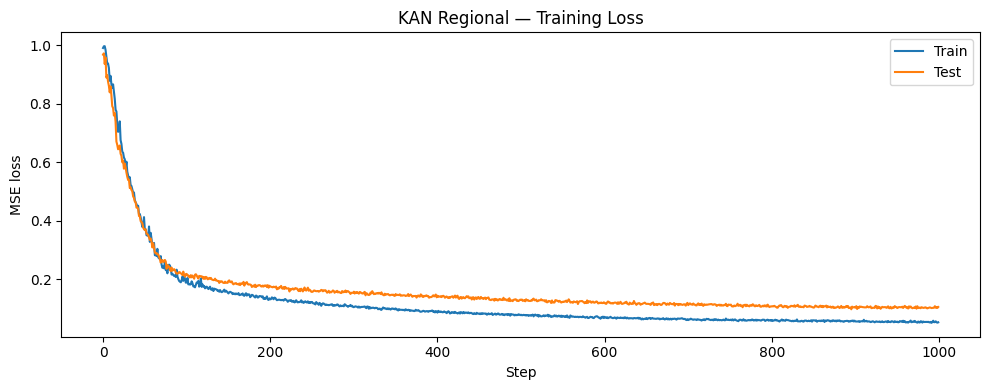

In [45]:
train_loss = results1['train_loss']
test_loss  = results1['test_loss']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_loss, label='Train')
ax.plot(test_loss,  label='Test')
ax.set_xlabel('Step')
ax.set_ylabel('MSE loss')
ax.set_title('KAN Regional — Training Loss')
ax.legend()
plt.tight_layout()
plt.show()

### 5. Evaluate on test set

In [49]:
model.eval()
with torch.no_grad():
    pred = model(dataset['test_input']).squeeze().numpy()
y_true = dataset['test_label'].squeeze().numpy()
rmse = np.sqrt(mean_squared_error(y_true, pred))
mae  = mean_absolute_error(y_true, pred)
r2   = r2_score(y_true, pred)

print(f'KAN Regional (per-station weather, train-only scaler)')
print(f'RMSE  {rmse:.4f} ({rmse * load_std:.0f} MW)')
print(f'MAE   {mae:.4f}  ({mae  * load_std:.0f} MW)')
print(f'R2    {r2:.4f}')

KAN Regional (per-station weather, train-only scaler)
RMSE  0.1020 (488 MW)
MAE   0.0743  (356 MW)
R2    0.9890


### 6. Predictions vs actuals (first 2 weeks of test)

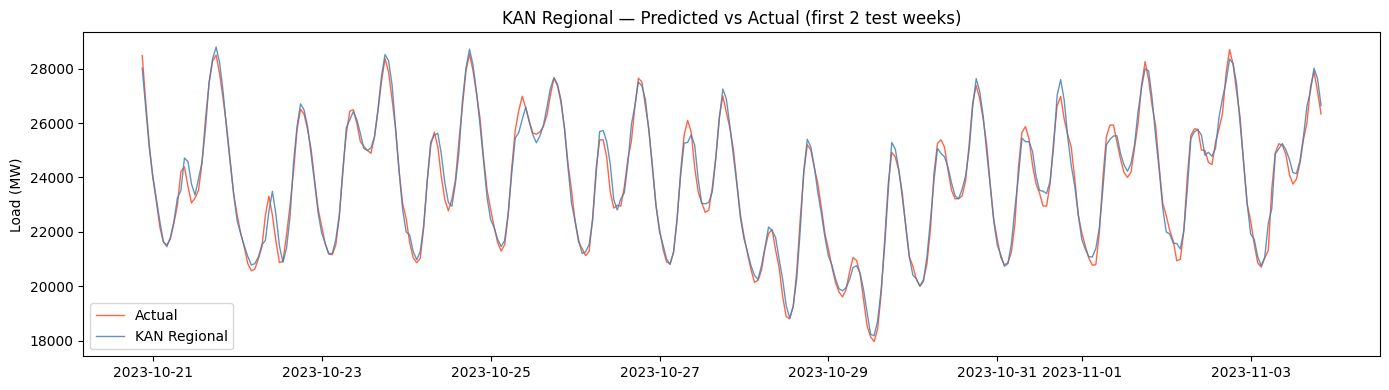

In [47]:
n      = 24 * 14
idx    = test.index[:n]
actual = y_true[:n] * load_std + load_mean

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(idx, actual, color='tomato', linewidth=1,label='Actual')
ax.plot(idx, pred[:n] * load_std + load_mean, color='steelblue', linewidth=1, alpha=0.85, label='KAN Regional')
ax.set_ylabel('Load (MW)')
ax.set_title('KAN Regional — Predicted vs Actual (first 2 test weeks)')
ax.legend()
plt.tight_layout()
plt.show()

### 7. KAN symbolic plot

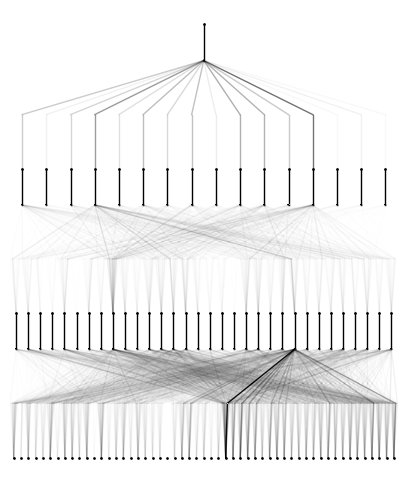

In [48]:
model.plot(beta=3)